# Advanced: Mixed-Phase Clouds

In this notebook, we'll build a idealized mixed-phase cloud profile from text files and include it in our simulation. Mixed-phase clouds — containing both liquid water and ice crystals — are common in the Arctic region.

In [1]:
import pyradtran  # Registers the .pyradtran xarray accessor
from pyradtran import load_config
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd
import logging

logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

# ── Solar config ─────────────────────────────────────────────────────────────
cfg_solar = load_config()
cfg_solar.simulation_defaults.rte_solver           = "disort"
cfg_solar.simulation_defaults.mol_abs_param        = "reptran per_nm"
cfg_solar.simulation_defaults.source               = "solar"
cfg_solar.simulation_defaults.wavelength_nm        = [400, 3200]
cfg_solar.simulation_defaults.integrate_wavelength = True
cfg_solar.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg_solar.execution.max_workers                    = 16
cfg_solar.execution.cleanup_temp_files             = False
solar_config_path = Path("config/cloud_solar.yaml")
cfg_solar.to_yaml(solar_config_path)

# ── Thermal config ────────────────────────────────────────────────────────────
cfg_thermal = load_config()
cfg_thermal.simulation_defaults.rte_solver           = "disort"
cfg_thermal.simulation_defaults.mol_abs_param        = "reptran medium"
cfg_thermal.simulation_defaults.source               = "thermal"
cfg_thermal.simulation_defaults.wavelength_nm        = [4500, 42000]
cfg_thermal.simulation_defaults.integrate_wavelength = True
cfg_thermal.simulation_defaults.output_columns       = ["zout", "lambda", "sza", "edir", "eglo", "edn", "eup", "enet", "albedo"]
cfg_thermal.execution.max_workers                    = 16
cfg_thermal.execution.cleanup_temp_files             = False
thermal_config_path = Path("config/cloud_thermal.yaml")
cfg_thermal.to_yaml(thermal_config_path)

print(f"Solar config:   {solar_config_path}")
print(f"Thermal config: {thermal_config_path}")

2026-04-18 18:01:53,690 - pyradtran.config - INFO - Configuration written to config/cloud_solar.yaml


2026-04-18 18:01:53,694 - pyradtran.config - INFO - Configuration written to config/cloud_thermal.yaml


Solar config:   config/cloud_solar.yaml
Thermal config: config/cloud_thermal.yaml


## Defining the Mixed-Phase Cloud Layers

A mixed-phase cloud in libRadtran is specified by providing **two separate files**: one for the liquid water component (`.wc`) and one for the ice crystal component (`.ic`). Each file lists altitude, content (LWC or IWC in g/m³), and effective radius (μm).

**Liquid water layer** (`water_cloud.wc`):
```text
#      z     LWC    R_eff
#     (km)  (g/m³)  (μm)
      4.000   5.0    15.0
      3.000   3.0    12.0
      2.000   0.0    10.0
```

**Ice crystal layer** (`ice_cloud.ic`):
```text
#      z     IWC    R_eff
#     (km)  (g/m³)  (μm)
    4.000     0.02    20.0
    3.000     0.02    20.0
    2.500     0.02    20.0
    2.000     0.02    20.0
```

We write both files to disk so they can be passed to pyRadtran.

In [2]:
wc_content = """\
#      z     LWC    R_eff
#     (km)  (g/m^3) (um)  
      4.000   5.0    15.0 
      3.000   3.0    12.0  
      2.000   0.0    10.0  
"""

ic_content = """\
#      z     IWC    R_eff
#     (km)  (g/m^3) (um)
    4.000     0.02    20.0
    3.000     0.02    20.0
    2.500     0.02    20.0
    2.000     0.02    20.0
"""

# Write both cloud definition files to the work directory
wc_file_path = Path('work/water_cloud.wc')
wc_file_path.parent.mkdir(parents=True, exist_ok=True)
wc_file_path.write_text(wc_content)
print(f"Water cloud definition written to {wc_file_path}")

ic_file_path = Path('work/ice_cloud.ic')
ic_file_path.parent.mkdir(parents=True, exist_ok=True)
ic_file_path.write_text(ic_content)
print(f"Ice cloud definition written to {ic_file_path}")

Water cloud definition written to work/water_cloud.wc
Ice cloud definition written to work/ice_cloud.ic


## Setting Up the Arctic Scenario

We define two simulation timesteps representing contrasting Arctic surface conditions:

1. **Open ocean** — low albedo (0.2) and surface temperature at 0 °C
2. **Sea ice** — high albedo (0.8) and surface temperature at −15 °C

This allows us to compare how the mixed-phase cloud's radiative effect changes over these two surfaces.

In [3]:
N_timesteps = 2

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2020-04-03T12:00:00', periods=N_timesteps, freq='s'),
        'latitude' : ('time', [80.0] * N_timesteps),
        'longitude' : ('time', [0.0] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 10, 0.5)),
    },
    data_vars={
        'surface_temperature' : ('time', [273.15, 273.15 - 15]),  # 0 °C and -15 °C
        'albedo' : ('time', [0.2, 0.8]),  # Ocean vs. sea-ice albedo
    }
)

ds

<xarray.Dataset> Size: 240B
Dimensions:              (time: 2, altitude: 20)
Coordinates:
  * time                 (time) datetime64[ns] 16B 2020-04-03T12:00:00 2020-0...
    latitude             (time) float64 16B 80.0 80.0
    longitude            (time) float64 16B 0.0 0.0
  * altitude             (altitude) float64 160B 0.0 0.5 1.0 1.5 ... 8.5 9.0 9.5
Data variables:
    surface_temperature  (time) float64 16B 273.1 258.1
    albedo               (time) float64 16B 0.2 0.8

## Loading an ERA5 Atmospheric Profile

To supply a realistic atmospheric profile (temperature, humidity, geopotential) for the simulation, we load ERA5 reanalysis data from Google Cloud Storage. The profile is selected at 80° N, 0° E on 3 April 2020 — matching our Arctic scenario.

/home/josh/micromamba/envs/mamba_josh/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


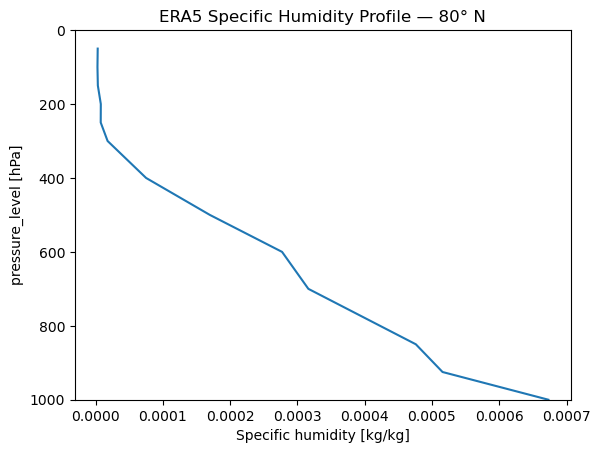

In [4]:
import gcsfs

# Access the ERA5 reanalysis data stored in Google Cloud Storage
gcs = gcsfs.GCSFileSystem(token='anon')
path = 'gs://gcp-public-data-arco-era5/ar/1959-2022-6h-128x64_equiangular_with_poles_conservative.zarr/'
full_era5 = xr.open_zarr(gcs.get_mapper(path), chunks='auto')

era5_to_sim = full_era5.rename({
    'sea_surface_temperature': 'surface_temperature',
    'temperature': 't',
    'specific_humidity': 'q',
    'geopotential': 'z',
    'level': 'pressure_level',
    'time' : 'valid_time',
})

era5_to_sim = era5_to_sim.sel(
    valid_time='2020-04-01T12:00:00',
    latitude=80.0,
    longitude=0.0,
    method='nearest'
).load()

# Assign units required by pyRadtran
era5_to_sim['t'].attrs['units'] = 'K'
era5_to_sim['q'].attrs['units'] = 'kg/kg'
era5_to_sim['z'].attrs['units'] = 'm'
era5_to_sim['pressure_level'].attrs['units'] = 'hPa'

# Quick look at the humidity profile
era5_to_sim['q'].plot(y='pressure_level')
plt.ylim(1000, 0)
plt.title('ERA5 Specific Humidity Profile — 80° N')
plt.show()

## Running Solar and Thermal Simulations

We run two separate simulations — **solar** (shortwave) and **thermal** (longwave) — each using our mixed-phase cloud files as overrides. The `wc_modify tau set 10` parameter normalises the liquid water cloud optical depth to 10.

In [5]:
ds_sim_solar = ds.pyradtran.run(
    config_path=solar_config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    albedo_var='albedo',
    era5_atmosphere=era5_to_sim,
    parameter_overrides={
        'wc_file 1D' : 'work/water_cloud.wc',
        'ic_file 1D' : 'work/ice_cloud.ic',
        'wc_modify tau set 10' : '',
    }
)

ds_sim_thermal = ds.pyradtran.run(
    config_path=thermal_config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    albedo_var='albedo',
    era5_atmosphere=era5_to_sim,
    parameter_overrides={
        'wc_file 1D' : 'work/water_cloud.wc',
        'ic_file 1D' : 'work/ice_cloud.ic',
        'wc_modify tau set 10' : '',
    }
)

Running simulations:   0%|          | 0/2 [00:00<?, ?sim/s]

Running simulations:  50%|█████     | 1/2 [00:05<00:05,  5.04s/sim]

Running simulations:  50%|█████     | 1/2 [00:05<00:05,  5.04s/sim, Success=1, Total=2]

Running simulations: 100%|██████████| 2/2 [00:05<00:00,  5.04s/sim, Success=2, Total=2]

Running simulations: 100%|██████████| 2/2 [00:05<00:00,  2.53s/sim, Success=2, Total=2]

Running simulations:   0%|          | 0/2 [00:00<?, ?sim/s]

Running simulations:  50%|█████     | 1/2 [00:01<00:01,  1.98s/sim]

Running simulations:  50%|█████     | 1/2 [00:01<00:01,  1.98s/sim, Success=1, Total=2]

Running simulations: 100%|██████████| 2/2 [00:01<00:00,  1.98s/sim, Success=2, Total=2]

Running simulations: 100%|██████████| 2/2 [00:01<00:00,  1.00sim/s, Success=2, Total=2]

## Visualising the Net Irradiance Profiles

Below we plot the net irradiance (thermal, solar, and total) as a function of altitude for each surface type. The grey shading marks the mixed-phase cloud layer (2–4 km).

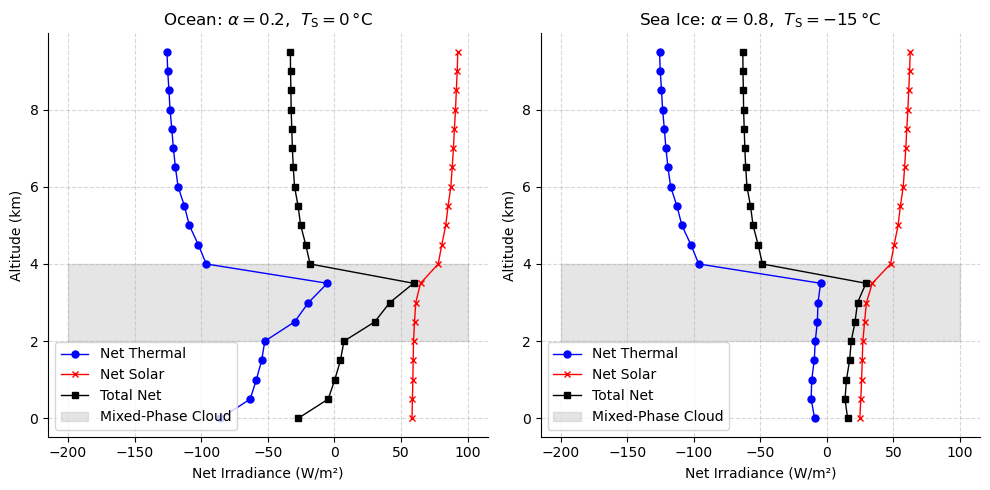

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# --- Left panel: open ocean ---
ds_sim_thermal.enet.isel(time=0).plot(y='altitude', ax=ax[0], marker='o', color='blue', label='Net Thermal', lw=1, markersize=5)
(ds_sim_solar/1e3).enet.isel(time=0).plot(y='altitude', ax=ax[0], marker='x', color='red', label='Net Solar', lw=1, markersize=5)
fnet = ds_sim_solar.enet.isel(time=0).values / 1e3 + ds_sim_thermal.enet.isel(time=0).values
ax[0].plot(fnet, ds_sim_solar.altitude, color='black', label='Total Net', lw=1, marker='s', markersize=5)
ax[0].fill_betweenx(np.arange(2, 5), -200, 100, color='gray', alpha=0.2, label='Mixed-Phase Cloud')
ax[0].set_xlabel('Net Irradiance (W/m²)')
ax[0].set_ylabel('Altitude (km)')
ax[0].legend()
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_title(r'Ocean: $\alpha=0.2$,  $T_\mathrm{S}=0\,$°C')

# --- Right panel: sea ice ---
ds_sim_thermal.enet.isel(time=1).plot(y='altitude', ax=ax[1], marker='o', color='blue', label='Net Thermal', lw=1, markersize=5)
(ds_sim_solar/1e3).enet.isel(time=1).plot(y='altitude', ax=ax[1], marker='x', color='red', label='Net Solar', lw=1, markersize=5)
fnet = ds_sim_solar.enet.isel(time=1).values / 1e3 + ds_sim_thermal.enet.isel(time=1).values
ax[1].plot(fnet, ds_sim_solar.altitude, color='black', label='Total Net', lw=1, marker='s', markersize=5)
ax[1].fill_betweenx(np.arange(2, 5), -200, 100, color='gray', alpha=0.2, label='Mixed-Phase Cloud')
ax[1].set_xlabel('Net Irradiance (W/m²)')
ax[1].set_ylabel('Altitude (km)')
ax[1].legend()
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_title(r'Sea Ice: $\alpha=0.8$,  $T_\mathrm{S}=-15\,$°C')

plt.tight_layout()
plt.show()